# Démo — My Logic Puzzle Solver
Comparaison CP-SAT / Z3 sur Zebra, Knights and Knaves, Picross et Sudoku.

In [2]:
import sys

sys.path.insert(0, "src")

import matplotlib.pyplot as plt
import pandas as pd

from my_logic_puzzle_solver.core.benchmark import run_benchmarks
from my_logic_puzzle_solver.core.solvers.cpsat import CPSATSolver
from my_logic_puzzle_solver.core.solvers.z3 import Z3Solver
from my_logic_puzzle_solver.puzzles import KnightsKnaves, Picross, Zebra
from my_logic_puzzle_solver.puzzles.sudoku import (
    SudokuBoolean,
    SudokuInteger,
    SudokuMixed,
)

## Zebra (Einstein)

In [3]:
zebra_cpsat = Zebra(CPSATSolver()).solve()
zebra_z3 = Zebra(Z3Solver()).solve()
assert zebra_cpsat == zebra_z3, (
    "CP-SAT et Z3 doivent converger vers la même solution"
)

df_zebra = pd.DataFrame(zebra_cpsat).T
df_zebra.index.name = "maison"
df_zebra

,nationality,color,drink,smoke,pet
maison,,,,,
1,Norwegian,yellow,<beverage>,Kools,fox
2,Ukrainian,blue,tea,ChesterFields,horse
3,Englishman,red,milk,Old Gold,snail
4,Japanese,green,coffee,Parliaments,<animal>
5,Spaniard,ivory,orange juice,Lucky Strike,dog


## Knights and Knaves
A dit : *"Nous sommes tous les deux des menteurs."*

In [4]:
persons = ["A", "B"]
statements = {
    "A": lambda k, s: s.bool_and(s.bool_not(k["A"]), s.bool_not(k["B"])),
}

for name, solver_cls in [("CP-SAT", CPSATSolver), ("Z3", Z3Solver)]:
    result = KnightsKnaves(solver_cls(), persons, statements).solve()
    print(f"{name}: {result}")

CP-SAT: {'A': 'knave', 'B': 'knight'}
Z3: {'A': 'knave', 'B': 'knight'}


## Picross

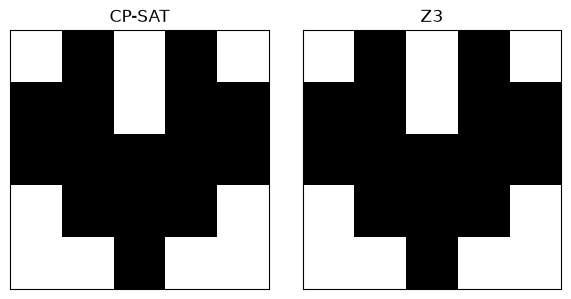

In [5]:
row_clues = [[1, 1], [2, 2], [5], [3], [1]]
col_clues = [[2], [4], [3], [4], [2]]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
for ax, (name, solver_cls) in zip(
    axes, [("CP-SAT", CPSATSolver), ("Z3", Z3Solver)]
):
    grid = Picross(solver_cls(), row_clues, col_clues).solve()
    ax.imshow(grid, cmap="Greys")
    ax.set_title(name)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## Sudoku — benchmark des encodages
Comparaison de 3 encodages (booléen, entier, mixte) sur CP-SAT et Z3.

In [6]:
sudoku_grid = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9],
]

encodings = [
    ("bool", SudokuBoolean),
    ("int", SudokuInteger),
    ("mixte", SudokuMixed),
]
solvers = [("CP-SAT", CPSATSolver), ("Z3", Z3Solver)]

cases = [
    (
        f"{enc_name}/{solver_name}",
        solver_cls,
        lambda s, cls=enc_cls: cls(s, sudoku_grid),
    )
    for enc_name, enc_cls in encodings
    for solver_name, solver_cls in solvers
]
results = run_benchmarks(cases)  # ty:ignore[invalid-argument-type]

df_bench = pd.DataFrame([r.__dict__ for r in results])
df_bench[["encoding", "solver"]] = df_bench["label"].str.split("/", expand=True)
df_bench

,label,solved,time_seconds,num_variables,num_constraints,encoding,solver
0,bool/CP-SAT,True,0.006787,729,354,bool,CP-SAT
1,bool/Z3,True,0.064300,729,354,bool,Z3
2,int/CP-SAT,True,0.011212,81,1002,int,CP-SAT
3,int/Z3,True,0.047854,81,1083,int,Z3
4,mixte/CP-SAT,True,0.004388,81,57,mixte,CP-SAT
5,mixte/Z3,True,0.027469,81,138,mixte,Z3


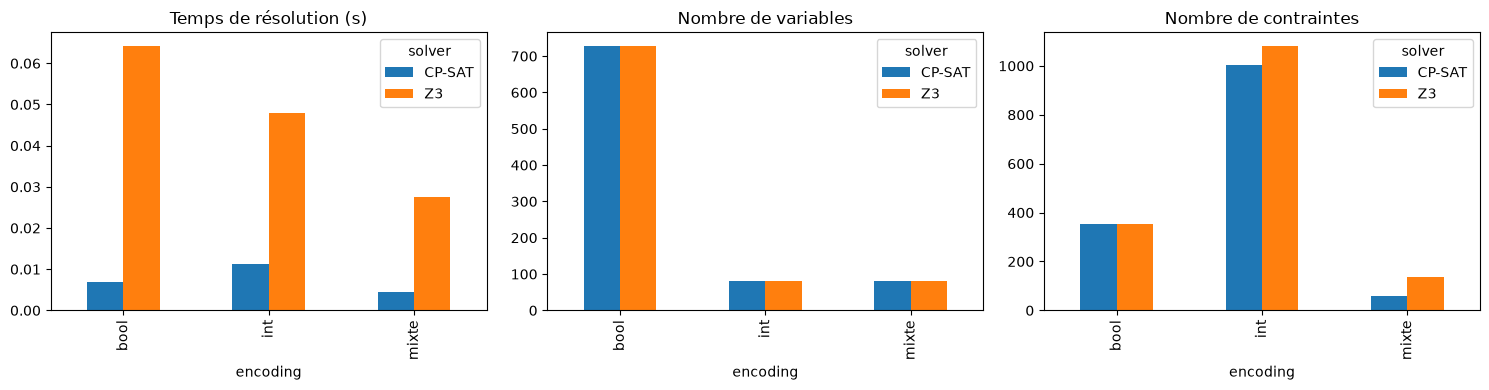

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_bench.pivot(
    index="encoding", columns="solver", values="time_seconds"
).plot.bar(ax=axes[0], title="Temps de résolution (s)")
df_bench.pivot(
    index="encoding", columns="solver", values="num_variables"
).plot.bar(ax=axes[1], title="Nombre de variables")
df_bench.pivot(
    index="encoding", columns="solver", values="num_constraints"
).plot.bar(ax=axes[2], title="Nombre de contraintes")

plt.tight_layout()
plt.show()

## Extension
*À compléter une fois le puzzle supplémentaire choisi et implémenté.*